# Synthetic biomarker benchmark — analysis

The generated pages hold the facts: [how it is run](../docs/benchmarks/biomarker-synthetic-docs.md)
and [what came out](../docs/benchmarks/biomarker-synthetic-pvbm-results.md). The shapes and the values
their geometry requires are in [the shapes notebook](biomarker-synthetic-shapes.ipynb). This
notebook is where the judgement goes.

**The question is not whether two implementations agree.** It is whether one of them computes the
quantity it is said to compute, measured against a number derived on paper. A straight vessel has a
tortuosity of exactly 1; an implementation that says otherwise is wrong, and the interesting part
is *by how much and in what pattern*, because the pattern says what it is doing instead.

Every shape was drawn at four angles. The geometry is identical at each, so anything that moves is
the grid or the implementation, never the retina.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def repository() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(f"nothing above {Path.cwd()} looks like the fundus-atlas repository")


ROOT = repository()
sys.path.insert(0, str(ROOT / "src"))
RESULTS = ROOT / "results" / "biomarker-synthetic"

from benchmarks import biomarker_synthetic as benchmark  # noqa: E402
from benchmarks.shapes import library  # noqa: E402
from biomarkers.utils import catalogue  # noqa: E402

#: Each adapter carries its own table from the implementation's column names onto catalogued ones,
#: and answers under the catalogued name, so the evidence needs no translation here. This is only
#: to show what was mapped onto what.
NAMES = catalogue.load("pvbm").declare()["names"]


def evidence() -> pd.DataFrame:
    """Every rendering, one row each, as the run recorded it."""
    frames = []
    for path in sorted(RESULTS.glob("*/*.csv")):
        frame = pd.read_csv(path)
        frame["implementation"] = path.parent.name
        frames.append(frame)
    if not frames:
        raise FileNotFoundError(f"no results in {RESULTS} — run the benchmark first")
    return pd.concat(frames, ignore_index=True)


def comparisons(rows: pd.DataFrame) -> pd.DataFrame:
    """One row per (rendering, quantity) where the shape defines a value to compare against.

    The evidence keeps what was said and what geometry requires side by side; putting them in one
    frame with the difference is the first thing an analysis does and the last thing the evidence
    should.
    """
    found = []
    for _, row in rows.iterrows():
        for column in rows.columns:
            if not column.startswith("said_"):
                continue
            key = column[len("said_") :]
            said, theory = row[column], row.get(f"theory_{key}")
            if pd.isna(said) or pd.isna(theory):
                continue
            found.append(
                {
                    "implementation": row["implementation"],
                    "shape": row["shape"],
                    "rotation": row["rotation"],
                    "column": key,
                    "canonical": row.get(f"canonical_{key}", ""),
                    "said": float(said),
                    "theory": float(theory),
                    "relative error": (float(said) - float(theory)) / float(theory)
                    if float(theory)
                    else np.nan,
                }
            )
    return pd.DataFrame(found)


rows = evidence()
compared = comparisons(rows)
print(f"{len(rows)} renderings · {compared['implementation'].nunique()} implementation(s) · "
      f"{compared['shape'].nunique()} shapes · {len(compared)} comparable measurements")
print("angles:", sorted(rows["rotation"].unique()))

32 renderings · 1 implementation(s) · 8 shapes · 262 comparable measurements
angles: [np.float64(0.0), np.float64(30.0), np.float64(60.0), np.float64(90.0)]


## 1. What was measured, and what could be compared

Three different things stand between a column PVBM computes and a number this benchmark can judge,
and keeping them apart is the first thing an analysis owes a reader:

- **The catalogue may have no name for it.** PVBM's perimeter, its singularity length and the three
  statistics of its branching angle describe quantities nothing else here computes. Those columns
  are measured and stored under PVBM's own names — a name exists to make two numbers comparable,
  and there is no second number yet.
- **No shape may define it.** A fractal dimension has a catalogued name and no shape here pins a
  value for it, so it is reported and not checked.
- **PVBM may not report it per class.** Several shapes state a value over the vessels as one class,
  `junction-counts/junctions/vessels` among them, and PVBM measures each class separately. Those
  values go unused rather than being compared against half the picture.

A column carrying a `/` is answered under a catalogued name; one without it is PVBM's own.

In [2]:
said_columns = sorted({c[len("said_"):] for c in rows.columns if c.startswith("said_")})
reported = [c for c in said_columns if rows[f"said_{c}"].notna().any()]
# A name carrying a `/` is a catalogued biomarker; one without it is PVBM's own, kept because the
# catalogue has no name for that quantity yet.
catalogued = [c for c in said_columns if "/" in c]
checkable = sorted(compared["column"].unique())

pd.DataFrame(
    {
        "columns PVBM computes": [len(said_columns)],
        "columns it returned a value for": [len(reported)],
        "columns with a catalogued name": [len(catalogued)],
        "columns kept under PVBM's own name": [len(said_columns) - len(catalogued)],
        "columns a shape gives a value to check": [len(checkable)],
    }
).T.rename(columns={0: "count"})

,count
columns PVBM computes,32
columns it returned a value for,32
columns with a catalogued name,22
columns kept under PVBM's own name,10
columns a shape gives a value to check,16


In [3]:
# What is reported but never checked, and why — the two reasons are different.
unchecked = []
for column in reported:
    if column in checkable:
        continue
    named = "/" in column
    unchecked.append(
        {
            "column": column,
            "PVBM calls it": NAMES[column],
            "why unchecked": "no shape defines it" if named else "the catalogue has no name for it",
        }
    )
pd.DataFrame(unchecked).set_index("column")

,PVBM calls it,why unchecked
column,,
fractal-dimension/multifractal-d0/artery,capacity_dimension_artery,no shape defines it
fractal-dimension/multifractal-d0/vein,capacity_dimension_vein,no shape defines it
fractal-dimension/multifractal-d1/artery,entropy_dimension_artery,no shape defines it
fractal-dimension/multifractal-d1/vein,entropy_dimension_vein,no shape defines it
fractal-dimension/multifractal-d2/artery,correlation_dimension_artery,no shape defines it
fractal-dimension/multifractal-d2/vein,correlation_dimension_vein,no shape defines it
mean_branching_angle_artery,mean_branching_angle_artery,the catalogue has no name for it
mean_branching_angle_vein,mean_branching_angle_vein,the catalogue has no name for it
median_branching_angle_artery,median_branching_angle_artery,the catalogue has no name for it


## 2. What PVBM gets exactly right

Two quantities land on the geometry at every shape and every angle. They are worth stating first,
because the rest of this notebook is about the ones that do not, and a reader should not come away
thinking the implementation is poor.

**Area** is measured across four shapes and two classes, 56 comparisons, never worse than 0.3% and
usually inside 0.05%. **Endpoint counts** are exact — 24 comparisons, not one of them off by one.
Both are what a careful implementation of an easy definition looks like.

In [4]:
EXACT = (
    "vessel-area-and-length/area/",
    "junction-counts/endpoints/",
    "junction-counts/junctions/",
)
exact = compared[compared["column"].str.startswith(EXACT)]
summary = (
    exact.groupby(["shape", "column"])["relative error"]
    .agg(worst=lambda e: e.abs().max(), mean="mean")
    .sort_values("worst")
)
summary.style.format("{:.2%}") if hasattr(summary, "style") else summary.round(4)

## 3. The tortuosity of a straight vessel, which must be 1

τ1 is arc length over chord length. On a straight vessel the arc **is** the chord, so the answer is
exactly 1 whatever the vessel's width, length or orientation.

PVBM returns 1.0007 at 0°, 1.0003 at 90°, and **1.0740 at 30° and 60°**.

That number is derivable, and deriving it says what the implementation is doing. Walk a digital
straight line at angle θ: per unit of true length it takes `cos θ − sin θ` orthogonal steps and
`sin θ` diagonal ones, and a naive chain code weights a diagonal as √2.

In [5]:
def chain_code_length(degrees: float) -> float:
    """What a √2-weighted walk along a digital straight line measures, per unit of true length."""
    theta = np.radians(degrees % 90)
    theta = min(theta, np.pi / 2 - theta)  # the walk is symmetric about 45°
    return float((np.cos(theta) - np.sin(theta)) + np.sqrt(2) * np.sin(theta))


straight = compared[(compared["shape"] == "straight") & (compared["column"] == "tortuosity/hart-tau1/artery")]
predicted = pd.DataFrame(
    {
        "angle": straight["rotation"].to_numpy(),
        "PVBM said": straight["said"].to_numpy(),
        "geometry requires": straight["theory"].to_numpy(),
        "naive chain code predicts": [chain_code_length(a) for a in straight["rotation"]],
    }
).set_index("angle")
predicted.round(4)

,PVBM said,geometry requires,naive chain code predicts
angle,,,
0.0,1.0007,1.0,1.0000
30.0,1.0740,1.0,1.0731
60.0,1.0740,1.0,1.0731
90.0,1.0003,1.0,1.0000


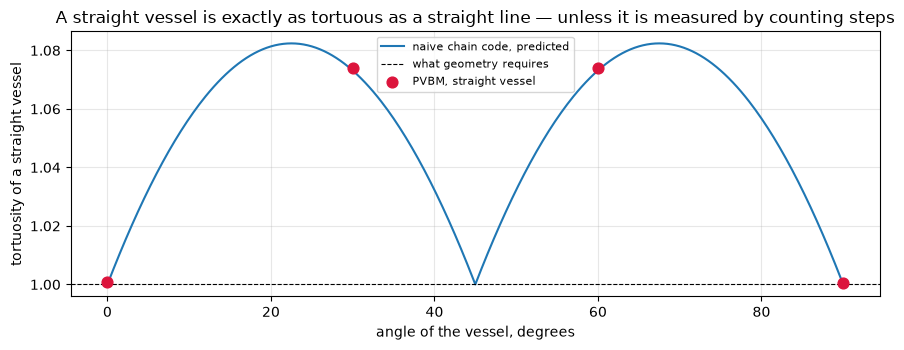

In [6]:
angles = np.linspace(0, 90, 361)
fig, axis = plt.subplots(figsize=(9, 3.6))
axis.plot(angles, [chain_code_length(a) for a in angles], label="naive chain code, predicted")
axis.axhline(1.0, color="black", linewidth=0.8, linestyle="--", label="what geometry requires")
axis.scatter(straight["rotation"], straight["said"], s=60, zorder=3, color="crimson",
             label="PVBM, straight vessel")
axis.set_xlabel("angle of the vessel, degrees")
axis.set_ylabel("tortuosity of a straight vessel")
axis.set_title("A straight vessel is exactly as tortuous as a straight line — unless it is measured by counting steps")
axis.legend(fontsize=8)
axis.grid(alpha=0.3)
fig.tight_layout()

**What follows from it.** The error is zero at 0°, 45° and 90°, and largest near 26.6°, where the
walk is 7.9% long. It is a property of measuring a digitised line by counting steps, and it is well
known — corrected estimators exist and have since the 1980s.

Three consequences for a reader of PVBM's tortuosity:

- A vessel's tortuosity depends on **how the eye happened to be oriented in the camera**. Two
  photographs of the same retina, one rotated, give different numbers.
- The bias is always **upward**: a straight vessel is never reported as less tortuous than straight.
- It does not vanish in a mean over many vessels, because it is a bias rather than noise. A study
  comparing two groups is safe only if their vessels are oriented alike, which is the sort of
  assumption nobody states.

## 4. Length, which is a sum of chords

PVBM's reported length is short on every shape, and by an amount that grows with how curved the
shape is: 0.1% on a straight vessel, 9.9% on a circular arc, 18.0% on a sinusoid.

Reading its source says why: the length it reports is `np.sum(chord)` — the straight-line distances
between branch points — not the distance travelled along the vessel. For a circular arc of angle θ
the ratio of chord to arc is `2 sin(θ/2) / θ`.

In [7]:
arc = library.build("arc", side=benchmark.SIDE)
theta = np.radians(arc.parameters["angle"])
chord_over_arc = float(2 * np.sin(theta / 2) / theta)

lengths = compared[compared["column"].str.startswith("vessel-area-and-length/skeleton-length/")]
by_shape = lengths.groupby("shape")["relative error"].agg(["mean", "min", "max"])
by_shape["what a chord sum would give"] = [
    chord_over_arc - 1 if shape == "arc" else np.nan for shape in by_shape.index
]
by_shape.round(4)

,mean,min,max,what a chord sum would give
shape,,,,
arc,-0.1010,-0.1127,-0.0979,-0.0997
artery-vein-pair,-0.0022,-0.0059,0.0006,NaN
bifurcation,-0.0078,-0.0091,-0.0037,NaN
disjoint,-0.0015,-0.0048,0.0005,NaN
sinusoid,-0.1814,-0.1909,-0.1790,NaN
spokes-disc-centred,-0.0043,-0.0080,-0.0009,NaN
spokes-macula-centred,-0.0023,-0.0047,0.0000,NaN
straight,-0.0007,-0.0039,0.0010,NaN


On the arc the prediction and the measurement agree: a chord sum should read 10.0% short and PVBM
reads 9.9% short.

**This is a definition rather than a defect** — but it is not the definition the name implies, and
PVBM's own docstring says "the overall length (in pixel)". A vessel length that is really a chord
sum under-reports every curved vessel, and the curviest most, which is exactly the direction that
would flatten a difference between a healthy retina and a tortuous one.

## 5. Counting junctions, where a single crossing becomes four

The bifurcation shape has exactly one junction. PVBM reports one, three or four depending on the
angle the same shape is drawn at.

In [8]:
counts = compared[
    compared["column"].isin(["junction-counts/junctions/artery", "junction-counts/endpoints/artery"])
    & compared["shape"].isin(["bifurcation", "disjoint", "straight"])
]
counts.pivot_table(
    index=["shape", "column"], columns="rotation", values="said", aggfunc="first"
).join(
    counts.groupby(["shape", "column"])["theory"].first().rename("geometry requires")
)

0.0  30.0  60.0  90.0  \
shape       column                                                    
bifurcation junction-counts/endpoints/artery  3.0   3.0   3.0   3.0   
            junction-counts/junctions/artery  4.0   4.0   3.0   1.0   
disjoint    junction-counts/endpoints/artery  8.0   8.0   8.0   8.0   
straight    junction-counts/endpoints/artery  2.0   2.0   2.0   2.0   

                                              geometry requires  
shape       column                                               
bifurcation junction-counts/endpoints/artery                3.0  
            junction-counts/junctions/artery                1.0  
disjoint    junction-counts/endpoints/artery                8.0  
straight    junction-counts/endpoints/artery                2.0

**Endpoints are exact everywhere; junctions are not.** A skeleton of a Y-shaped vessel has a small
cluster of pixels at the meeting point, and PVBM counts each of them rather than merging the cluster
into one junction. How many appear depends on how the branches fall on the pixel lattice, which is
why turning the shape changes the count.

A junction count is an input to branching-angle work and to any measure of network complexity, so
an error here propagates. It is also the easiest of these to fix: the cluster is a connected
component a few pixels across.

## 6. The branching angle, which claims to be nothing

PVBM reports 112° to 124° where the daughters of the bifurcation are 60° apart.

Reading `compute_angles_dictionary`: at every particular point it takes **every pair** of connected
neighbours and measures the angle between them, then reports the median of all of them. On a
symmetric Y the angles at the junction are 60° between the daughters and 150° between each daughter
and the trunk, so the median of what it collects is nothing like the angle a reader of "branching
angle" expects.

**This used to be recorded as the largest error on the page. It is not an error at all** — it was
this repository's mapping being wrong, and the mapping is now gone: `median_branching_angle` maps to
no catalogued biomarker, so nothing is compared and nothing is claimed. The column is still measured
and stored under PVBM's own name, together with the mean and the spread it returns from the same
call, because it is a real quantity measured consistently. What is missing is a catalogued
definition of what it actually is.

That is why the table below reads from the evidence rather than from the comparisons: with no
mapping there is no theory beside it.

In [9]:
# This column maps to nothing catalogued now, so it carries no theory and is absent from
# `compared`. It is read straight from the evidence and set against what the shape is known to be:
# a symmetric Y whose daughters are 60° apart, and whose trunk therefore meets each daughter at 150°.
angles = rows[rows["shape"] == "bifurcation"][["rotation", "said_median_branching_angle_artery"]]
pd.DataFrame(
    {
        "rotation": angles["rotation"].to_numpy(),
        "PVBM said": angles["said_median_branching_angle_artery"].to_numpy(),
        "angle between the daughters": 60.0,
        "angle between a daughter and the trunk": 150.0,
    }
).set_index("rotation").round(2)

,PVBM said,angle between the daughters,angle between a daughter and the trunk
rotation,,,
0.0,79.71,60.0,150.0
30.0,133.98,60.0,150.0
60.0,133.06,60.0,150.0
90.0,80.66,60.0,150.0


## 7. The central retinal equivalents

Three families reach the ring these are measured over — the two spokes framings and the pair — and
what comes back separates the two variants completely.

- **Knudtson's recursion is reproduced, and low everywhere.** On the twelve spokes it is 6.3% low on
  CRAE and 2.6% low on CRVE; on the pair, 4.2% and 1.3%. It is low on every shape at every angle,
  never high, which is what a rasterisation deficit looks like and not what noise looks like: a mask
  is slightly narrower than the vessel that was drawn. Knudtson's recursion is linear in the widths,
  so those percentages *are* the width deficit: between **0.31 and 1.01 pixels** across the four
  measurements. It is **proportionally larger for the artery**, the narrower class — 80 µm against
  120, sixteen pixels against twenty-four — because a fixed loss at the boundary costs a thin vessel
  more of its width than a thick one.
- **The arteriovenous ratio inherits both deficits and keeps most of the cancellation**: 3.8% low on
  the spokes, 3.0% on the pair. Better than the artery it is built from, worse than the vein.
- **Hubbard's variant is not a unit conversion away from being right**: 81% low on the artery, 73% on
  the vein. PVBM feeds **pixel** widths into constants fitted in **microns**, and its additive term
  does not scale, so the two classes are out by different factors — 5.4× and 3.6× at one and the
  same 5 µm per pixel. Two different factors is the arithmetic proof that no single conversion
  recovers it.

**And the two framings agree to three decimal places.** `spokes-macula-centred` and
`spokes-disc-centred` are the same retina photographed with the disc off to one side and in the
middle of the frame; PVBM returns 26.203 for CRAE on both, and 49.949 against 49.946 for CRVE. A
disc-anchored measurement that read the framing rather than the eye would have shown it here, and
this one does not.

In [10]:
EQUIVALENTS = [
    "said_central-retinal-equivalents/knudtson/artery",
    "said_central-retinal-equivalents/knudtson/vein",
    "said_central-retinal-equivalents/hubbard/artery",
    "said_central-retinal-equivalents/hubbard/vein",
    "theory_central-retinal-equivalents/knudtson/artery",
]
reaching = ["spokes-macula-centred", "spokes-disc-centred", "artery-vein-pair"]
rows[rows["shape"].isin(reaching)].set_index(["shape", "rotation"])[EQUIVALENTS].round(3)

said_central-retinal-equivalents/knudtson/artery  \
shape                 rotation                                                     
artery-vein-pair      0.0                                                    NaN   
                      30.0                                                15.323   
                      60.0                                                15.328   
                      90.0                                                   NaN   
spokes-disc-centred   0.0                                                 26.203   
                      30.0                                                26.203   
                      60.0                                                26.203   
                      90.0                                                26.203   
spokes-macula-centred 0.0                                                 26.203   
                      30.0                                                26.203   
                      60.0                                                26.203   
                      90.0                                                26.203   

                                said_central-retinal-equivalents/knudtson/vein  \
shape                 rotation                                                   
artery-vein-pair      0.0                                                  NaN   
                      30.0                                              23.696   
                      60.0                                              23.693   
                      90.0                                                 NaN   
spokes-disc-centred   0.0                                               49.949   
                      30.0                                              49.949   
                      60.0                                              49.949   
                      90.0                                              49.949   
spokes-macula-centred 0.0                                               49.946   
                      30.0                                              49.946   
                      60.0                                              49.946   
                      90.0                                              49.946   

                                said_central-retinal-equivalents/hubbard/artery  \
shape                 rotation                                                    
artery-vein-pair      0.0                                                   NaN   
                      30.0                                               15.323   
                      60.0                                               15.328   
                      90.0                                                  NaN   
spokes-disc-centred   0.0                                                28.281   
                      30.0                                               28.281   
                      60.0                                               28.281   
                      90.0                                               28.281   
spokes-macula-centred 0.0                                                28.281   
                      30.0                                               28.281   
                      60.0                                               28.281   
                      90.0                                               28.282   

                                said_central-retinal-equivalents/hubbard/vein  \
shape                 rotation                                                  
artery-vein-pair      0.0                                                 NaN   
                      30.0                                             23.696   
                      60.0                                             23.693   
                      90.0                                                NaN   
spokes-disc-centred   0.0                                

**The recursion limit is the finding worth carrying forward**, because it depends on the image
rather than on the eye.

`compute_central_retinal_equivalents` walks each vessel with `tree.recursive_reg`, which calls
itself once per skeleton pixel. The straight shape's artery skeletonises to about 1220 pixels
against Python's default limit of 1000, so the call dies; raising the limit to 50,000 and changing
nothing else makes the same call return a number, which is the test of the diagnosis. The same
vessel on a 512-pixel frame skeletonises to 400 pixels and is measured without complaint.

It cost **10 of the 32 renderings** their equivalents in this run — every angle of the straight and
sinusoid families, and half of the artery/vein pair.

Worse, **whether it happens depends on the orientation.** On the artery/vein pair the equivalents
die at 0° and 90° and succeed at 30° and 60°, because a tilted digital line spends fewer pixels
covering the same distance — a diagonal step advances by √2. The same vessel in the same eye is
measurable or not according to how the camera was held.

It fails loudly rather than returning a wrong number, which is much the better of the two failure
modes; but anyone running PVBM on a modern 2048-pixel photograph is nearer this cliff than anyone
running it on the small images its examples use.

## 8. Does it turn with the image?

The geometry is identical at every angle, so any spread across the four is the implementation or the
grid. This is the summary of that, per quantity — the one table to read if you read nothing else.

In [11]:
spread = (
    compared.groupby(["shape", "column"])
    .agg(
        required=("theory", "first"),
        lowest=("said", "min"),
        highest=("said", "max"),
        worst_error=("relative error", lambda e: e.abs().max()),
    )
)
spread["turns by"] = (spread["highest"] - spread["lowest"]).abs() / spread["required"].abs()
spread.sort_values("turns by", ascending=False).round(4)

required  \
shape               column                                                    
bifurcation         junction-counts/junctions/vein                   1.0000   
                    junction-counts/junctions/artery                 1.0000   
straight            tortuosity/hart-tau1/artery                      1.0000   
artery-vein-pair    tortuosity/hart-tau1/vein                        1.0000   
                    tortuosity/hart-tau1/artery                      1.0000   
...                                                                     ...   
spokes-disc-centred central-retinal-equivalents/knudtson/artery     27.9749   
                    central-retinal-equivalents/hubbard/artery     151.7217   
bifurcation         junction-counts/endpoints/artery                 3.0000   
                    junction-counts/endpoints/vein                   3.0000   
spokes-disc-centred vessel-area-and-length/area/vein             59738.3361   

                                                                     lowest  \
shape               column                                                    
bifurcation         junction-counts/junctions/vein                   1.0000   
                    junction-counts/junctions/artery                 1.0000   
straight            tortuosity/hart-tau1/artery                      1.0003   
artery-vein-pair    tortuosity/hart-tau1/vein                        1.0000   
                    tortuosity/hart-tau1/artery                      1.0000   
...                                                                     ...   
spokes-disc-centred central-retinal-equivalents/knudtson/artery     26.2030   
                    central-retinal-equivalents/hubbard/artery      28.2812   
bifurcation         junction-counts/endpoints/artery                 3.0000   
                    junction-counts/endpoints/vein                   3.0000   
spokes-disc-centred vessel-area-and-length/area/vein             59728.0000   

                                                                    highest  \
shape               column                                                    
bifurcation         junction-counts/junctions/vein                   4.0000   
                    junction-counts/junctions/artery                 4.0000   
straight            tortuosity/hart-tau1/artery                      1.0740   
artery-vein-pair    tortuosity/hart-tau1/vein                        1.0732   
                    tortuosity/hart-tau1/artery                      1.0730   
...                                                                     ...   
spokes-disc-centred central-retinal-equivalents/knudtson/artery     26.2030   
                    central-retinal-equivalents/hubbard/artery      28.2812   
bifurcation         junction-counts/endpoints/artery                 3.0000   
                    junction-counts/endpoints/vein                   3.0000   
spokes-disc-centred vessel-area-and-length/area/vein             59728.0000   

                                                                 worst_error  \
shape               column                                                     
bifurcation         junction-counts/junctions/vein                    3.0000   
                    junction-counts/junctions/artery                  3.0000   
straight            tortuosity/hart-tau1/artery                       0.0740   
artery-vein-pair    tortuosity/hart-tau1/vein                         0.0732   
                    tortuosity/hart-tau1/artery                       0.0730   
...                                                                      ...   
spokes-disc-centred central-retinal-equivalents/knudtson/artery       0.0633   
                    central-retinal-equivalents/hubbard/artery        0.8136   
bifurcation         junction-counts/endpoints/artery                  0.0000   
                    junction-counts/endpoints/vein                    0.0000   
spokes-disc-centred ves

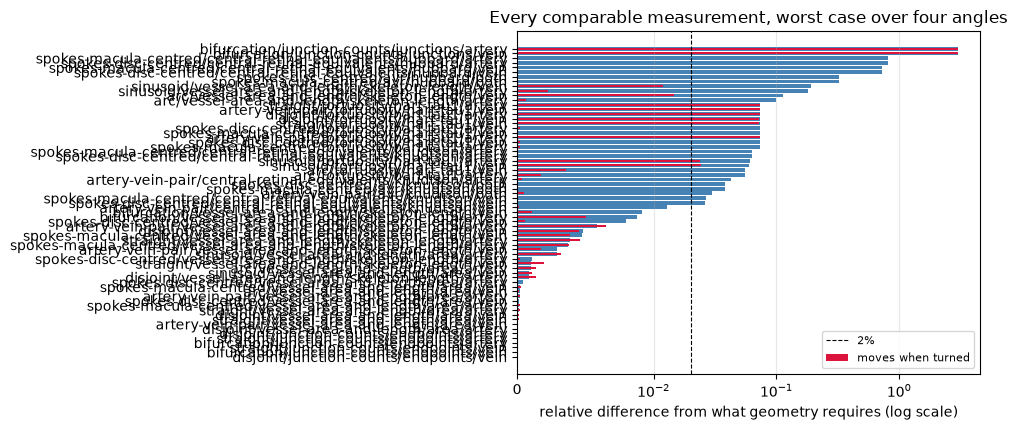

In [12]:
fig, axis = plt.subplots(figsize=(10, 4.4))
ordered = spread.sort_values("worst_error")
labels = [f"{shape}/{column}" for shape, column in ordered.index]
axis.barh(labels, ordered["worst_error"], color="steelblue")
axis.barh(labels, ordered["turns by"], color="crimson", height=0.45, label="moves when turned")
axis.set_xscale("symlog", linthresh=0.01)
axis.axvline(0.02, color="black", linewidth=0.8, linestyle="--", label="2%")
axis.set_xlabel("relative difference from what geometry requires (log scale)")
axis.set_title("Every comparable measurement, worst case over four angles")
axis.legend(fontsize=8, loc="lower right")
axis.grid(axis="x", alpha=0.3)
fig.tight_layout()

## 9. What this analysis cannot say

- **Nothing about photographs.** Every shape here is clean, binary and noiseless. An implementation
  that measures a synthetic vessel exactly may still fail on a segmentation of a real eye, where the
  mask has holes, specks and a boundary nobody agrees on. That is the next benchmark's question.
- **Nothing about which implementation to use**, because there is one here. The comparison this
  benchmark exists to make needs a second, and the naming table is built to take one.
- **Nothing about a quantity no shape defines.** PVBM's fractal dimensions, its perimeter and its
  singularity length are computed and recorded on every shape here, and none of them is checked:
  the shapes define no value they could be checked against. A fractal dimension of a
  straight line is defensibly 1, and a shape that pinned it would be worth adding.
- **Nothing about a scale.** Every shape was built at 5 µm per pixel and PVBM ignores the figure
  entirely, so nothing here tests a conversion. What it does test is that its Hubbard equivalents
  are computed from pixel widths, which the results page records.
- **The 2% used to call something "agreeing" is arbitrary.** It is a reporting convenience, not a
  standard, and no implementation is selected or rejected by it here.